Ultralytics version: 8.4.7
Устройство для обучения: cuda
GPU: NVIDIA GeForce GTX 1060 6GB
Проверка структуры датасета...
✓ Найден файл: data.yaml
✓ Найден файл: classes.txt
✓ Директория train/images: 104 изображений
✓ Директория train/labels: 104 файлов разметки
✓ Директория val/images: 38 изображений
✓ Директория val/labels: 38 файлов разметки

ЭТАП 1: ОБУЧЕНИЕ МОДЕЛИ

НАЧАЛО ОБУЧЕНИЯ МОДЕЛИ YOLO
✓ Файл data.yaml подготовлен: yolo_dataset\data.yaml

Создание модели YOLOv8n...

Параметры обучения:
  epochs: 50
  imgsz: 640
  batch: 8
  workers: 2
  device: cuda
  patience: 20
  save: True
  save_period: 5
  exist_ok: True
  pretrained: True
  optimizer: SGD
  lr0: 0.01
  lrf: 0.01
  momentum: 0.937
  weight_decay: 0.0005
  warmup_epochs: 3
  warmup_momentum: 0.8
  box: 7.5
  cls: 0.5
  dfl: 1.5
  verbose: True
  seed: 42

Начало обучения...
New https://pypi.org/project/ultralytics/8.4.8 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.7  Python-3.13.6 torch-2.6.0+cu1

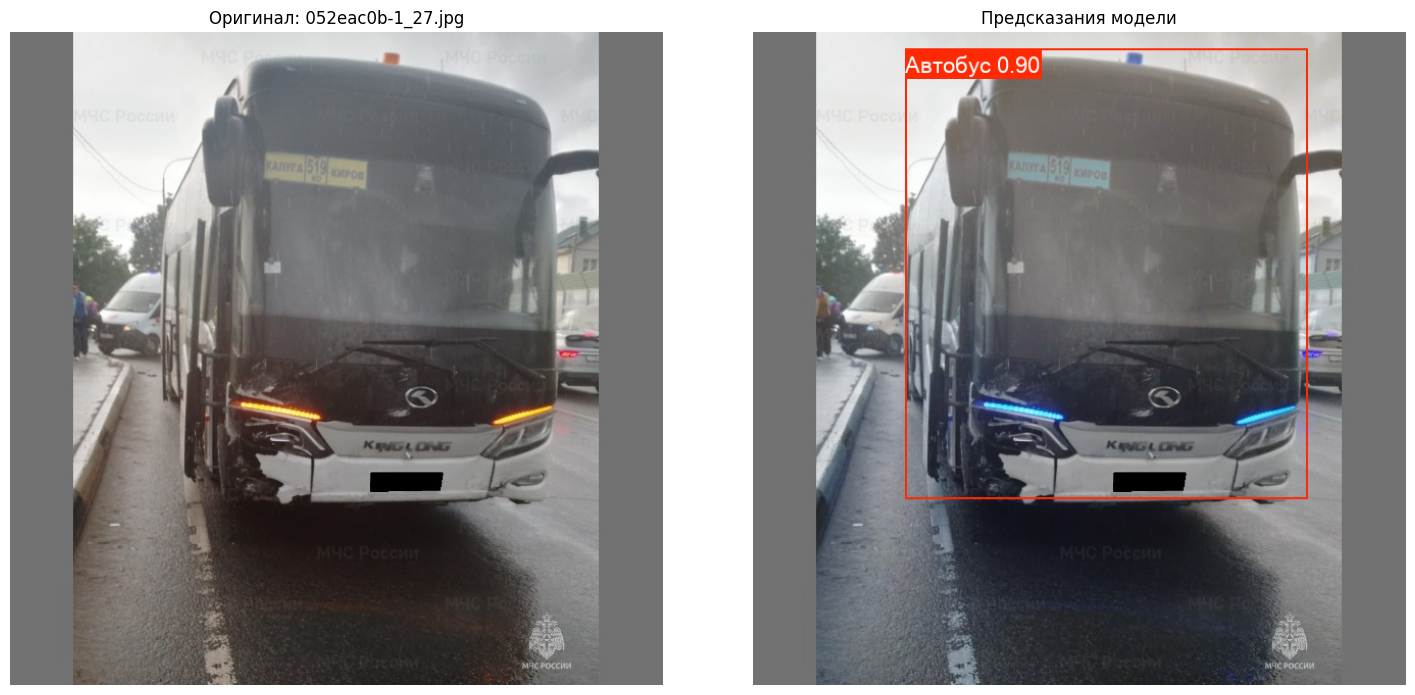


Изображение 2: 0ae29847-1_80.jpg
  Найдено объектов: 2
    Объект 1: класс=0, уверенность=0.659
    Объект 2: класс=3, уверенность=0.268


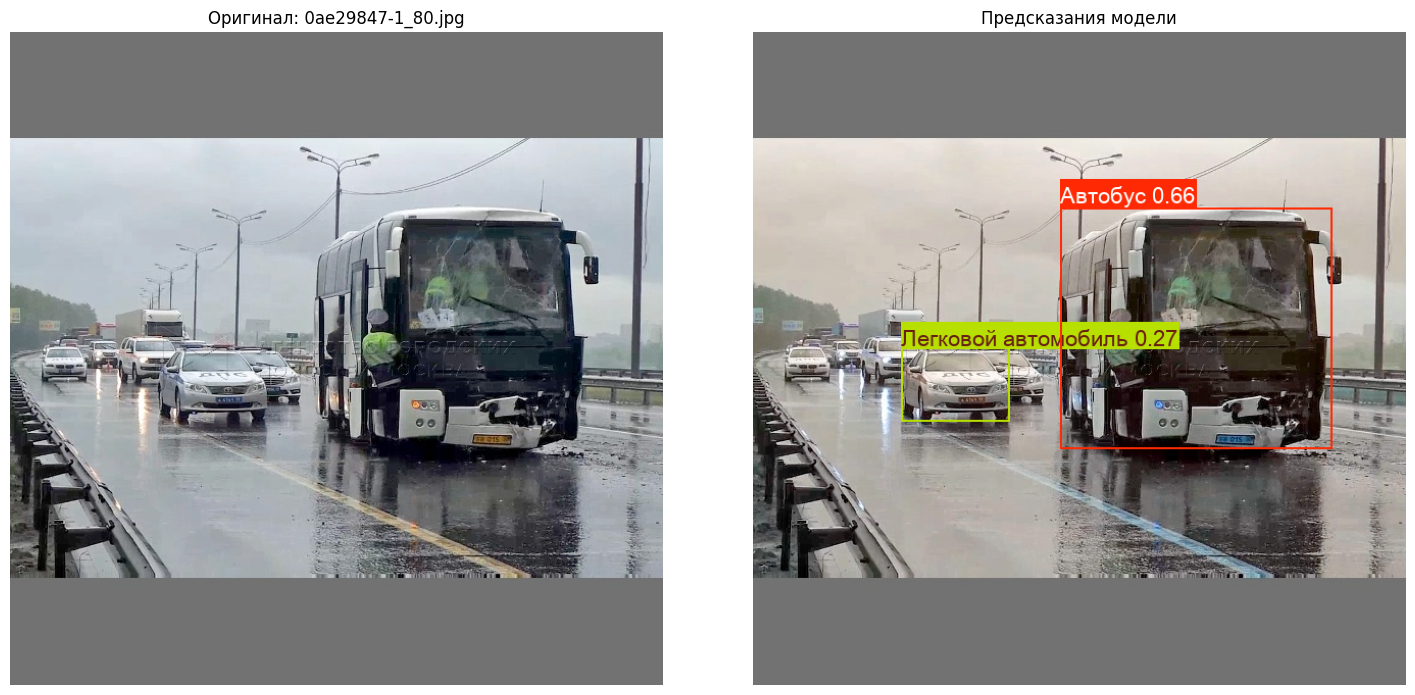


ОБУЧЕНИЕ ЗАВЕРШЕНО!

Результаты сохранены в:
  - Модель: yolo_dataset/best_model.pt
  - Логи обучения: yolo_dataset/../runs/train/
  - Конфигурация: yolo_dataset/data.yaml


In [12]:
import torch
import yaml
from ultralytics import YOLO
import os
import matplotlib.pyplot as plt
import cv2
import numpy as np
from pathlib import Path

class YOLOTrainer:
    def __init__(self, dataset_dir, model_size='n', device='cpu', epochs=50, imgsz=640):
        """
        Инициализация тренера YOLO
        
        Args:
            dataset_dir: Путь к датасету в формате YOLO
            model_size: Размер модели ('n', 's', 'm', 'l', 'x')
            device: Устройство для обучения ('cpu' или 'cuda')
            epochs: Количество эпох обучения
            imgsz: Размер изображения
        """
        self.dataset_dir = Path(dataset_dir)
        self.model_size = model_size
        self.device = device
        self.epochs = epochs
        self.imgsz = imgsz
        
        # Проверяем наличие датасета
        self._validate_dataset()
        
    def _validate_dataset(self):
        """Проверка структуры датасета"""
        required_files = ['data.yaml', 'classes.txt']
        required_dirs = ['train/images', 'train/labels', 'val/images', 'val/labels']
        
        print("Проверка структуры датасета...")
        
        # Проверка файлов
        for file in required_files:
            file_path = self.dataset_dir / file
            if not file_path.exists():
                raise FileNotFoundError(f"Отсутствует файл: {file_path}")
            print(f"✓ Найден файл: {file}")
        
        # Проверка директорий
        for dir_path in required_dirs:
            full_path = self.dataset_dir / dir_path
            if not full_path.exists():
                raise FileNotFoundError(f"Отсутствует директория: {full_path}")
            
            # Проверяем наличие файлов в директориях
            if 'images' in dir_path:
                images = list(full_path.glob('*.*'))
                if len(images) == 0:
                    print(f"⚠ Внимание: Директория {dir_path} пуста")
                else:
                    print(f"✓ Директория {dir_path}: {len(images)} изображений")
            
            if 'labels' in dir_path:
                labels = list(full_path.glob('*.txt'))
                if len(labels) == 0:
                    print(f"⚠ Внимание: Директория {dir_path} пуста")
                else:
                    print(f"✓ Директория {dir_path}: {len(labels)} файлов разметки")
    
    def prepare_data_yaml(self):
        """Подготовка data.yaml файла для YOLO"""
        data_yaml_path = self.dataset_dir / 'data.yaml'
        
        # Сначала читаем classes.txt
        classes_path = self.dataset_dir / 'classes.txt'
        with open(classes_path, 'r', encoding='utf-8') as f:
            classes = [line.strip() for line in f if line.strip()]
        
        # Создаем data.yaml с правильной структурой
        data = {
            'path': str(self.dataset_dir.absolute()),
            'train': 'train/images',
            'val': 'val/images',
            'nc': len(classes),
            'names': classes
        }
        
        # Проверяем наличие тестовых данных
        test_images_path = self.dataset_dir / 'test/images'
        if test_images_path.exists() and len(list(test_images_path.glob('*.*'))) > 0:
            data['test'] = 'test/images'
        
        # Сохраняем файл
        with open(data_yaml_path, 'w', encoding='utf-8') as f:
            yaml.dump(data, f, default_flow_style=False, allow_unicode=True)
        
        print(f"✓ Файл data.yaml подготовлен: {data_yaml_path}")
        return str(data_yaml_path)
    
    def train(self):
        """Обучение модели YOLO"""
        print("\n" + "="*50)
        print("НАЧАЛО ОБУЧЕНИЯ МОДЕЛИ YOLO")
        print("="*50)
        
        # Подготавливаем data.yaml
        data_yaml_path = self.prepare_data_yaml()
        
        # Создаем модель YOLO
        print(f"\nСоздание модели YOLOv8{self.model_size}...")
        model = YOLO(f'yolov8{self.model_size}.pt')  # Предварительно обученная модель
        
        # Настраиваем параметры обучения
        train_args = {
            'data': data_yaml_path,
            'epochs': self.epochs,
            'imgsz': self.imgsz,
            'batch': 8,  # Уменьшаем размер батча для стабильности
            'workers': 2,  # Уменьшаем количество воркеров
            'device': self.device,
            'patience': 20,  # Увеличиваем patience для ранней остановки
            'save': True,
            'save_period': 5,  # Сохранять каждые 5 эпох
            'project': str(self.dataset_dir.parent / 'runs'),
            'name': 'train',
            'exist_ok': True,
            'pretrained': True,
            'optimizer': 'SGD',  # SGD часто работает лучше для детекции
            'lr0': 0.01,  # Начальная скорость обучения
            'lrf': 0.01,  # Конечная скорость обучения
            'momentum': 0.937,
            'weight_decay': 0.0005,
            'warmup_epochs': 3,
            'warmup_momentum': 0.8,
            'box': 7.5,  # Вес для loss bounding box
            'cls': 0.5,  # Вес для loss классификации
            'dfl': 1.5,  # Вес для DFL loss
            'verbose': True,
            'seed': 42,
        }
        
        # Запускаем обучение
        print(f"\nПараметры обучения:")
        for key, value in train_args.items():
            if key not in ['data', 'project', 'name']:
                print(f"  {key}: {value}")
        
        print("\nНачало обучения...")
        try:
            results = model.train(**train_args)
        except Exception as e:
            print(f"Ошибка при обучении: {e}")
            print("Пробуем с более простыми параметрами...")
            # Пробуем с упрощенными параметрами
            train_args_simple = {
                'data': data_yaml_path,
                'epochs': self.epochs,
                'imgsz': self.imgsz,
                'batch': 4,
                'workers': 1,
                'device': self.device,
                'patience': 10,
                'save': True,
                'project': str(self.dataset_dir.parent / 'runs'),
                'name': 'train_simple',
                'exist_ok': True,
            }
            results = model.train(**train_args_simple)
        
        print(f"\n✓ Обучение завершено!")
        print(f"Результаты сохранены в: {self.dataset_dir.parent / 'runs/train'}")
        
        # Сохраняем лучшую модель
        best_model_path = Path(results.save_dir) / 'weights' / 'best.pt'
        if best_model_path.exists():
            # Просто копируем файл модели (не пытаемся загружать state_dict)
            import shutil
            target_path = self.dataset_dir / 'best_model.pt'
            shutil.copy2(best_model_path, target_path)
            print(f"✓ Лучшая модель сохранена в: {target_path}")
        
        return model, results
    
    def validate_model(self, model_path=None):
        """Валидация обученной модели"""
        print("\n" + "="*50)
        print("ВАЛИДАЦИЯ МОДЕЛИ")
        print("="*50)
        
        if model_path is None:
            # Пробуем разные пути
            possible_paths = [
                self.dataset_dir / 'best_model.pt',
                self.dataset_dir.parent / 'runs/train/weights/best.pt',
                self.dataset_dir.parent / 'runs/train_simple/weights/best.pt',
            ]
            
            for path in possible_paths:
                if path.exists():
                    model_path = path
                    break
        
        if model_path is None or not model_path.exists():
            print("⚠ Модель для валидации не найдена")
            print("Проверьте наличие файлов в runs/train/weights/")
            return None
        
        print(f"Загрузка модели: {model_path}")
        
        try:
            # Загружаем модель
            model = YOLO(str(model_path))
            
            # Валидация
            data_yaml_path = self.dataset_dir / 'data.yaml'
            
            print(f"\nВыполнение валидации на данных: {data_yaml_path}")
            results = model.val(
                data=str(data_yaml_path),
                imgsz=self.imgsz,
                batch=4,
                device=self.device,
                conf=0.25,
                iou=0.45,
                verbose=True
            )
            
            # Выводим метрики
            print("\n" + "="*50)
            print("МЕТРИКИ ВАЛИДАЦИИ:")
            print("="*50)
            
            if hasattr(results, 'box'):
                print(f"  mAP50: {results.box.map50:.4f}")
                print(f"  mAP50-95: {results.box.map:.4f}")
                print(f"  Precision: {results.box.p:.4f}")
                print(f"  Recall: {results.box.r:.4f}")
            else:
                print("  Метрики детекции недоступны")
            
            return results
            
        except Exception as e:
            print(f"❌ Ошибка при валидации: {e}")
            return None
    
    def visualize_predictions(self, model_path=None, num_images=3):
        """Визуализация предсказаний модели"""
        print("\n" + "="*50)
        print("ВИЗУАЛИЗАЦИЯ ПРЕДСКАЗАНИЙ")
        print("="*50)
        
        if model_path is None:
            # Ищем модель
            possible_paths = [
                self.dataset_dir / 'best_model.pt',
                self.dataset_dir.parent / 'runs/train/weights/best.pt',
            ]
            
            for path in possible_paths:
                if path.exists():
                    model_path = path
                    break
        
        if model_path is None or not model_path.exists():
            print("⚠ Модель для визуализации не найдена")
            return
        
        try:
            # Загружаем модель
            model = YOLO(str(model_path))
            
            # Загружаем валидационные изображения
            val_dir = self.dataset_dir / 'val/images'
            images = list(val_dir.glob('*.*'))[:num_images]
            
            if len(images) == 0:
                print("⚠ Нет изображений для визуализации")
                return
            
            print(f"\nВизуализация предсказаний для {len(images)} изображений...")
            
            for i, img_path in enumerate(images):
                print(f"\nИзображение {i+1}: {img_path.name}")
                
                # Загружаем оригинальное изображение
                img = cv2.imread(str(img_path))
                if img is None:
                    print(f"  ⚠ Не удалось загрузить изображение")
                    continue
                
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
                # Делаем предсказание
                try:
                    results = model(img_path, conf=0.25, verbose=False)
                except Exception as e:
                    print(f"  ⚠ Ошибка при предсказании: {e}")
                    continue
                
                # Проверяем результаты
                if len(results) == 0:
                    print("  Объекты не обнаружены")
                    continue
                    
                # Визуализируем результаты
                fig, axes = plt.subplots(1, 2, figsize=(15, 7))
                
                # Оригинальное изображение
                axes[0].imshow(img_rgb)
                axes[0].set_title(f'Оригинал: {img_path.name}')
                axes[0].axis('off')
                
                # Изображение с предсказаниями
                try:
                    result_img = results[0].plot()
                    axes[1].imshow(result_img)
                    axes[1].set_title('Предсказания модели')
                    axes[1].axis('off')
                    
                    # Выводим информацию о детекциях
                    if hasattr(results[0], 'boxes') and results[0].boxes is not None:
                        num_boxes = len(results[0].boxes)
                        print(f"  Найдено объектов: {num_boxes}")
                        for j in range(min(3, num_boxes)):  # Показываем первые 3
                            box = results[0].boxes[j]
                            cls_id = int(box.cls[0]) if box.cls.numel() > 0 else 0
                            conf = float(box.conf[0]) if box.conf.numel() > 0 else 0
                            print(f"    Объект {j+1}: класс={cls_id}, уверенность={conf:.3f}")
                        if num_boxes > 3:
                            print(f"    ... и еще {num_boxes-3} объектов")
                except Exception as e:
                    print(f"  ⚠ Ошибка при визуализации: {e}")
                    axes[1].text(0.5, 0.5, 'Ошибка визуализации', 
                               ha='center', va='center', fontsize=12)
                    axes[1].axis('off')
                
                plt.tight_layout()
                plt.show()
                
        except Exception as e:
            print(f"❌ Ошибка при визуализации: {e}")
            import traceback
            traceback.print_exc()
    
    def test_single_image(self, image_path, model_path=None, conf_threshold=0.25):
        """Тестирование модели на одном изображении"""
        print(f"\nТестирование на изображении: {image_path}")
        
        if model_path is None:
            model_path = self.dataset_dir / 'best_model.pt'
        
        if not model_path.exists():
            print("⚠ Модель не найдена")
            return
        
        try:
            # Загружаем модель
            model = YOLO(str(model_path))
            
            # Загружаем изображение
            img = cv2.imread(str(image_path))
            if img is None:
                print("⚠ Не удалось загрузить изображение")
                return
            
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # Делаем предсказание
            results = model(image_path, conf=conf_threshold)
            
            # Визуализируем
            fig, axes = plt.subplots(1, 2, figsize=(15, 7))
            
            axes[0].imshow(img_rgb)
            axes[0].set_title('Оригинал')
            axes[0].axis('off')
            
            if len(results) > 0 and hasattr(results[0], 'boxes'):
                result_img = results[0].plot()
                axes[1].imshow(result_img)
                axes[1].set_title('Результат детекции')
                print(f"Найдено объектов: {len(results[0].boxes)}")
            else:
                axes[1].imshow(img_rgb)
                axes[1].set_title('Объекты не найдены')
                print("Объекты не найдены")
            
            axes[1].axis('off')
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"❌ Ошибка: {e}")


def main():
    """Основная функция для обучения модели детекции"""
    
    # Параметры
    DATASET_DIR = "yolo_dataset"  # Путь к вашему датасету
    MODEL_SIZE = 'n'  # n, s, m, l, x
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    EPOCHS = 50
    IMAGE_SIZE = 640
    
    print(f"Устройство для обучения: {DEVICE}")
    if DEVICE == 'cuda':
        print(f"GPU: {torch.cuda.get_device_name(0)}")
    else:
        print("⚠ Обучение на CPU может быть медленным")
    
    # Создаем и запускаем тренер
    trainer = YOLOTrainer(
        dataset_dir=DATASET_DIR,
        model_size=MODEL_SIZE,
        device=DEVICE,
        epochs=EPOCHS,
        imgsz=IMAGE_SIZE
    )
    
    try:
        # Этап 1: Обучение модели
        print("\n" + "="*50)
        print("ЭТАП 1: ОБУЧЕНИЕ МОДЕЛИ")
        print("="*50)
        model, training_results = trainer.train()
        
        # Этап 2: Валидация модели
        print("\n" + "="*50)
        print("ЭТАП 2: ВАЛИДАЦИЯ МОДЕЛИ")
        print("="*50)
        validation_results = trainer.validate_model()
        
        # Этап 3: Визуализация предсказаний
        print("\n" + "="*50)
        print("ЭТАП 3: ВИЗУАЛИЗАЦИЯ ПРЕДСКАЗАНИЙ")
        print("="*50)
        trainer.visualize_predictions(num_images=2)
        
        # Этап 4: Тестирование на своем изображении (опционально)
        test_image = "test_image.jpg"  # Укажите путь к тестовому изображению
        if Path(test_image).exists():
            print("\n" + "="*50)
            print("ЭТАП 4: ТЕСТИРОВАНИЕ НА НОВОМ ИЗОБРАЖЕНИИ")
            print("="*50)
            trainer.test_single_image(test_image)
        
        print("\n" + "="*50)
        print("ОБУЧЕНИЕ ЗАВЕРШЕНО!")
        print("="*50)
        print("\nРезультаты сохранены в:")
        print(f"  - Модель: {DATASET_DIR}/best_model.pt")
        print(f"  - Логи обучения: {DATASET_DIR}/../runs/train/")
        print(f"  - Конфигурация: {DATASET_DIR}/data.yaml")
        
    except Exception as e:
        print(f"\n❌ Ошибка при обучении: {e}")
        import traceback
        traceback.print_exc()


if __name__ == "__main__":
    # Проверяем установку Ultralytics
    try:
        import ultralytics
        print(f"Ultralytics version: {ultralytics.__version__}")
    except ImportError:
        print("Установка Ultralytics...")
        import subprocess
        import sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "ultralytics"])
        print("Ultralytics успешно установлен!")
    
    # Запускаем обучение
    main()